<a href="https://colab.research.google.com/github/sonikasri04/insurance-premium-predictor/blob/main/Health_insurance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Run this first cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
from google.colab import files
uploaded = files.upload()

Saving enhanced_health_insurance_claims.csv to enhanced_health_insurance_claims.csv
Saving insurance.csv to insurance.csv


In [4]:
df1 = pd.read_csv('insurance.csv')
df2 = pd.read_csv('enhanced_health_insurance_claims.csv')

print("=== Insurance Dataset ===")
print(df1.shape)
print(df1.head())

print("\n=== Enhanced Claims Dataset ===")
print(df2.shape)
print(df2.head())

=== Insurance Dataset ===
(1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

=== Enhanced Claims Dataset ===
(4500, 17)
                                ClaimID                             PatientID  \
0  10944daf-f7d5-4e1d-8216-72ffa609fe41  8552381d-7960-4f64-b190-b20b8ada00a1   
1  fcbebb25-fc24-4c0f-a966-749edcf83fb1  327f43ad-e3bd-4473-a9ed-46483a0a156f   
2  9e9983e7-9ea7-45f5-84d8-ce49ccd8a4a1  6f3acdf7-73aa-4afa-9c2e-b25b27bdb5b0   
3  a06273ed-44bb-452b-bbad-8618de080494  5d58e183-701e-406c-a8c6-5b73cac5e912   
4  f702a717-254b-4cff-a0c7-8395db2f6616  8a8ebdf6-3af0-4f14-82f3-37b937c3d270   

                             ProviderID  ClaimAmo

In [5]:
print("=== Insurance Dataset ===")
print(df1.isnull().sum())
print("\nBasic Stats:")
print(df1.describe())

print("\n=== Enhanced Claims Dataset ===")
print(df2.isnull().sum())
print("\nBasic Stats:")
print(df2[['ClaimAmount', 'PatientAge', 'PatientIncome']].describe())

=== Insurance Dataset ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Basic Stats:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

=== Enhanced Claims Dataset ===
ClaimID                    0
PatientID                  0
ProviderID                 0
ClaimAmount                0
ClaimDate                  0
DiagnosisCode              0
ProcedureCode              0
PatientAge                 0
PatientGender              0
ProviderSpecialty       

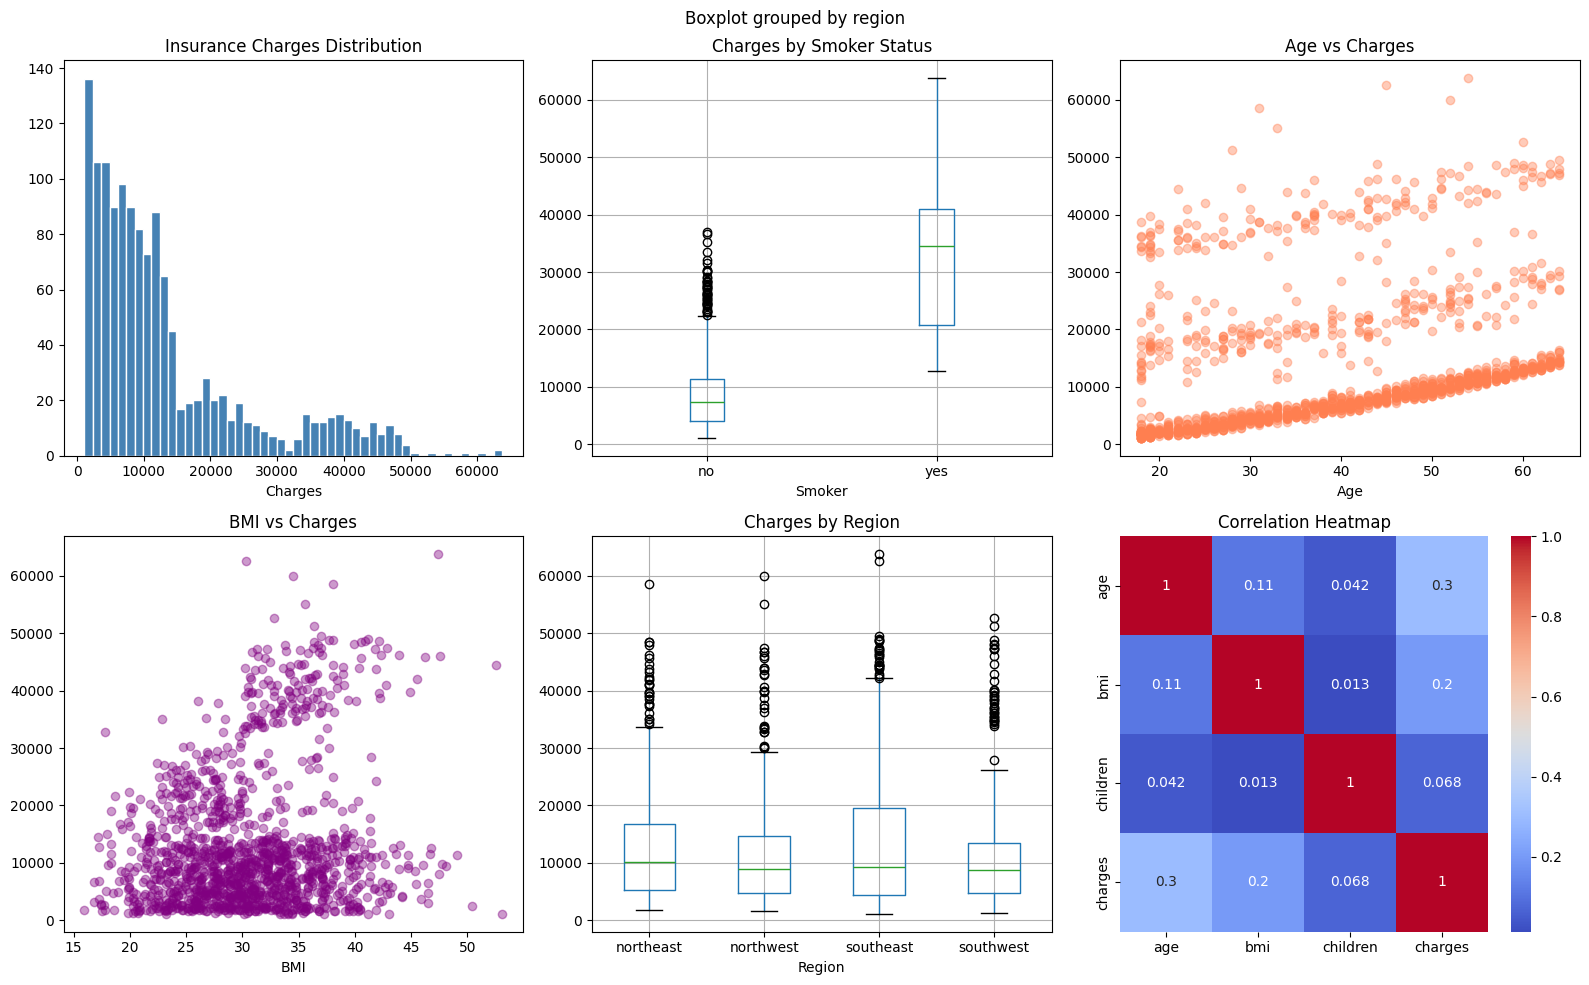

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Charges distribution
axes[0,0].hist(df1['charges'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Insurance Charges Distribution')
axes[0,0].set_xlabel('Charges')

# 2. Smoker vs charges
df1.boxplot(column='charges', by='smoker', ax=axes[0,1])
axes[0,1].set_title('Charges by Smoker Status')
axes[0,1].set_xlabel('Smoker')

# 3. Age vs charges
axes[0,2].scatter(df1['age'], df1['charges'], alpha=0.4, color='coral')
axes[0,2].set_title('Age vs Charges')
axes[0,2].set_xlabel('Age')

# 4. BMI vs charges
axes[1,0].scatter(df1['bmi'], df1['charges'], alpha=0.4, color='purple')
axes[1,0].set_title('BMI vs Charges')
axes[1,0].set_xlabel('BMI')

# 5. Charges by region
df1.boxplot(column='charges', by='region', ax=axes[1,1])
axes[1,1].set_title('Charges by Region')
axes[1,1].set_xlabel('Region')

# 6. Correlation heatmap
corr = df1[['age','bmi','children','charges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [7]:
# Encode categoricals + create interaction features
df_model = df1.copy()

# Encode
df_model['smoker'] = (df_model['smoker'] == 'yes').astype(int)
df_model['sex'] = (df_model['sex'] == 'male').astype(int)
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True)

# Interaction features (these will boost model performance)
df_model['bmi_smoker'] = df_model['bmi'] * df_model['smoker']
df_model['age_smoker'] = df_model['age'] * df_model['smoker']
df_model['age_bmi'] = df_model['age'] * df_model['bmi']

print(df_model.head())
print(df_model.shape)

   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  bmi_smoker  age_smoker  age_bmi  
0             False              True        27.9          19  530.100  
1              True             False         0.0           0  607.860  
2              True             False         0.0           0  924.000  
3             False             False         0.0           0  749.265  
4             False             False         0.0           0  924.160  
(1338, 12)


In [8]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df_model.drop('charges', axis=1)
y = df_model['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    cv = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    results[name] = {'RMSE': round(rmse, 2), 'R²': round(r2, 3), 'CV R²': round(cv, 3)}
    print(f"{name}: RMSE={rmse:.2f} | R²={r2:.3f} | CV R²={cv:.3f}")

Linear Regression: RMSE=4567.93 | R²=0.866 | CV R²=0.837
Random Forest: RMSE=4481.40 | R²=0.871 | CV R²=0.837
XGBoost: RMSE=4848.48 | R²=0.849 | CV R²=0.816


In [9]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

best = grid.best_estimator_
preds = best.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"Best params: {grid.best_params_}")
print(f"Tuned Random Forest: RMSE={rmse:.2f} | R²={r2:.3f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Tuned Random Forest: RMSE=4406.38 | R²=0.875


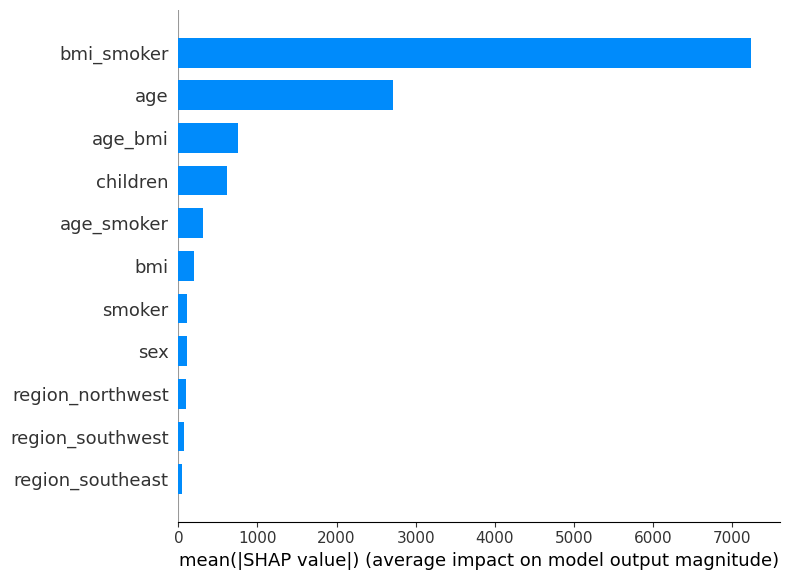

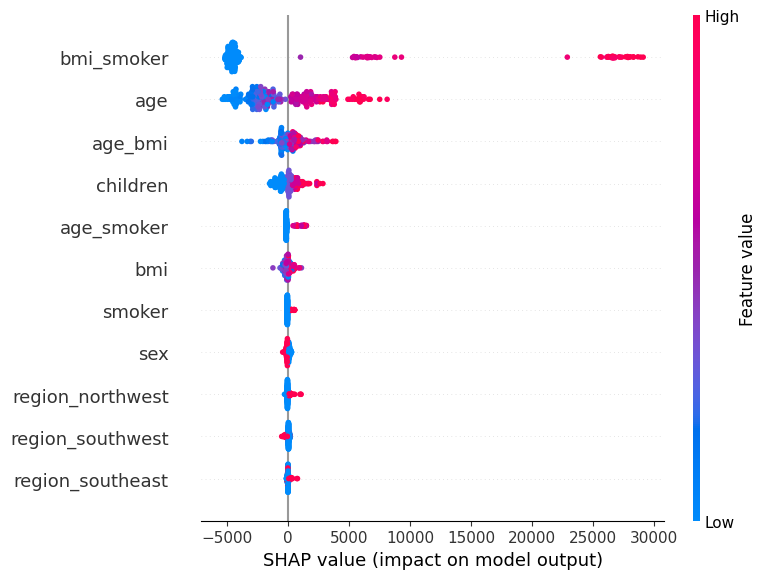

In [10]:
import shap

explainer = shap.TreeExplainer(best)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

plt.figure()
shap.summary_plot(shap_values, X_test, show=True)

In [11]:
# Bias check — does model treat sex and region fairly?
df_test = X_test.copy()
df_test['actual'] = y_test.values
df_test['predicted'] = best.predict(X_test)
df_test['error'] = df_test['actual'] - df_test['predicted']

print("=== Error by Sex (0=female, 1=male) ===")
print(df_test.groupby('sex')['error'].agg(['mean','std']).round(2))

print("\n=== Error by Smoker ===")
print(df_test.groupby('smoker')['error'].agg(['mean','std']).round(2))

=== Error by Sex (0=female, 1=male) ===
       mean      std
sex                 
0    -87.32  4372.86
1   -620.22  4432.60

=== Error by Smoker ===
          mean      std
smoker                 
0      -380.92  4365.80
1      -187.00  4577.98


In [12]:
import joblib

joblib.dump(best, 'insurance_model.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')

print("Model saved!")

Model saved!


In [13]:
from google.colab import files
files.download('insurance_model.pkl')
files.download('feature_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>